In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score,precision_score, recall_score, f1_score



In [2]:
cred_risk = pd.read_csv('/content/credit_risk_dataset.csv')

In [3]:
cred_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
print('Basic information about the dataset:\n')
cred_risk.info()

Basic information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3

In [5]:
# Data Describtion
cred_risk.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
print(f'Shape of the dataset is : {cred_risk.shape}')

Shape of the dataset is : (32581, 12)


## Data Cleaning


In [7]:
# Copy original dataset
cred_risk_copy = cred_risk.copy()

In [8]:
# Checking for dublicate values
print(f'Number of dublicate rows are: {cred_risk_copy.duplicated().sum()}')

Number of dublicate rows are: 165


In [9]:
# Remove dublicate rows
cred_risk_copy = cred_risk_copy.drop_duplicates()
print(f'Number of dublicated rows are: {cred_risk_copy.duplicated().sum()}')

Number of dublicated rows are: 0


In [10]:
# Clearing Irrelevant Data
cred_risk_copy.loc[cred_risk_copy['person_age'] > 100, 'person_age'] = 100
cred_risk_copy.loc[cred_risk_copy['person_age'] < 18, 'person_age'] = 18
cred_risk_copy.loc[cred_risk_copy['person_emp_length'] > 100,'person_emp_length'] = 100

In [11]:
# Identify null values and fill them
print(f'Number of null values in the dataset: {cred_risk_copy.isnull().sum()}')
print(f'Before removal of null values, the shape of the dataset is: {cred_risk_copy.shape}')
cred_risk_copy['person_emp_length'].fillna(cred_risk_copy['person_emp_length'].mean(),inplace = True)
cred_risk_copy['loan_int_rate'].fillna(cred_risk_copy['loan_int_rate'].mean(),inplace = True)
print(f'After removal of null values, the shape of the dataset is: {cred_risk_copy.shape}')


Number of null values in the dataset: person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Before removal of null values, the shape of the dataset is: (32416, 12)
After removal of null values, the shape of the dataset is: (32416, 12)


/tmp/ipython-input-2394557236.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cred_risk_copy['person_emp_length'].fillna(cred_risk_copy['person_emp_length'].mean(),inplace = True)
/tmp/ipython-input-2394557236.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [12]:
print(f'Number of null values in the dataset: {cred_risk_copy.isnull().sum()}')

Number of null values in the dataset: person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## Data Visualizaiton and outlier removal

In [13]:
num_cols = cred_risk_copy.select_dtypes(include = ['int64','float64']).columns
num_cols = num_cols.drop('loan_status')
print(num_cols)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')


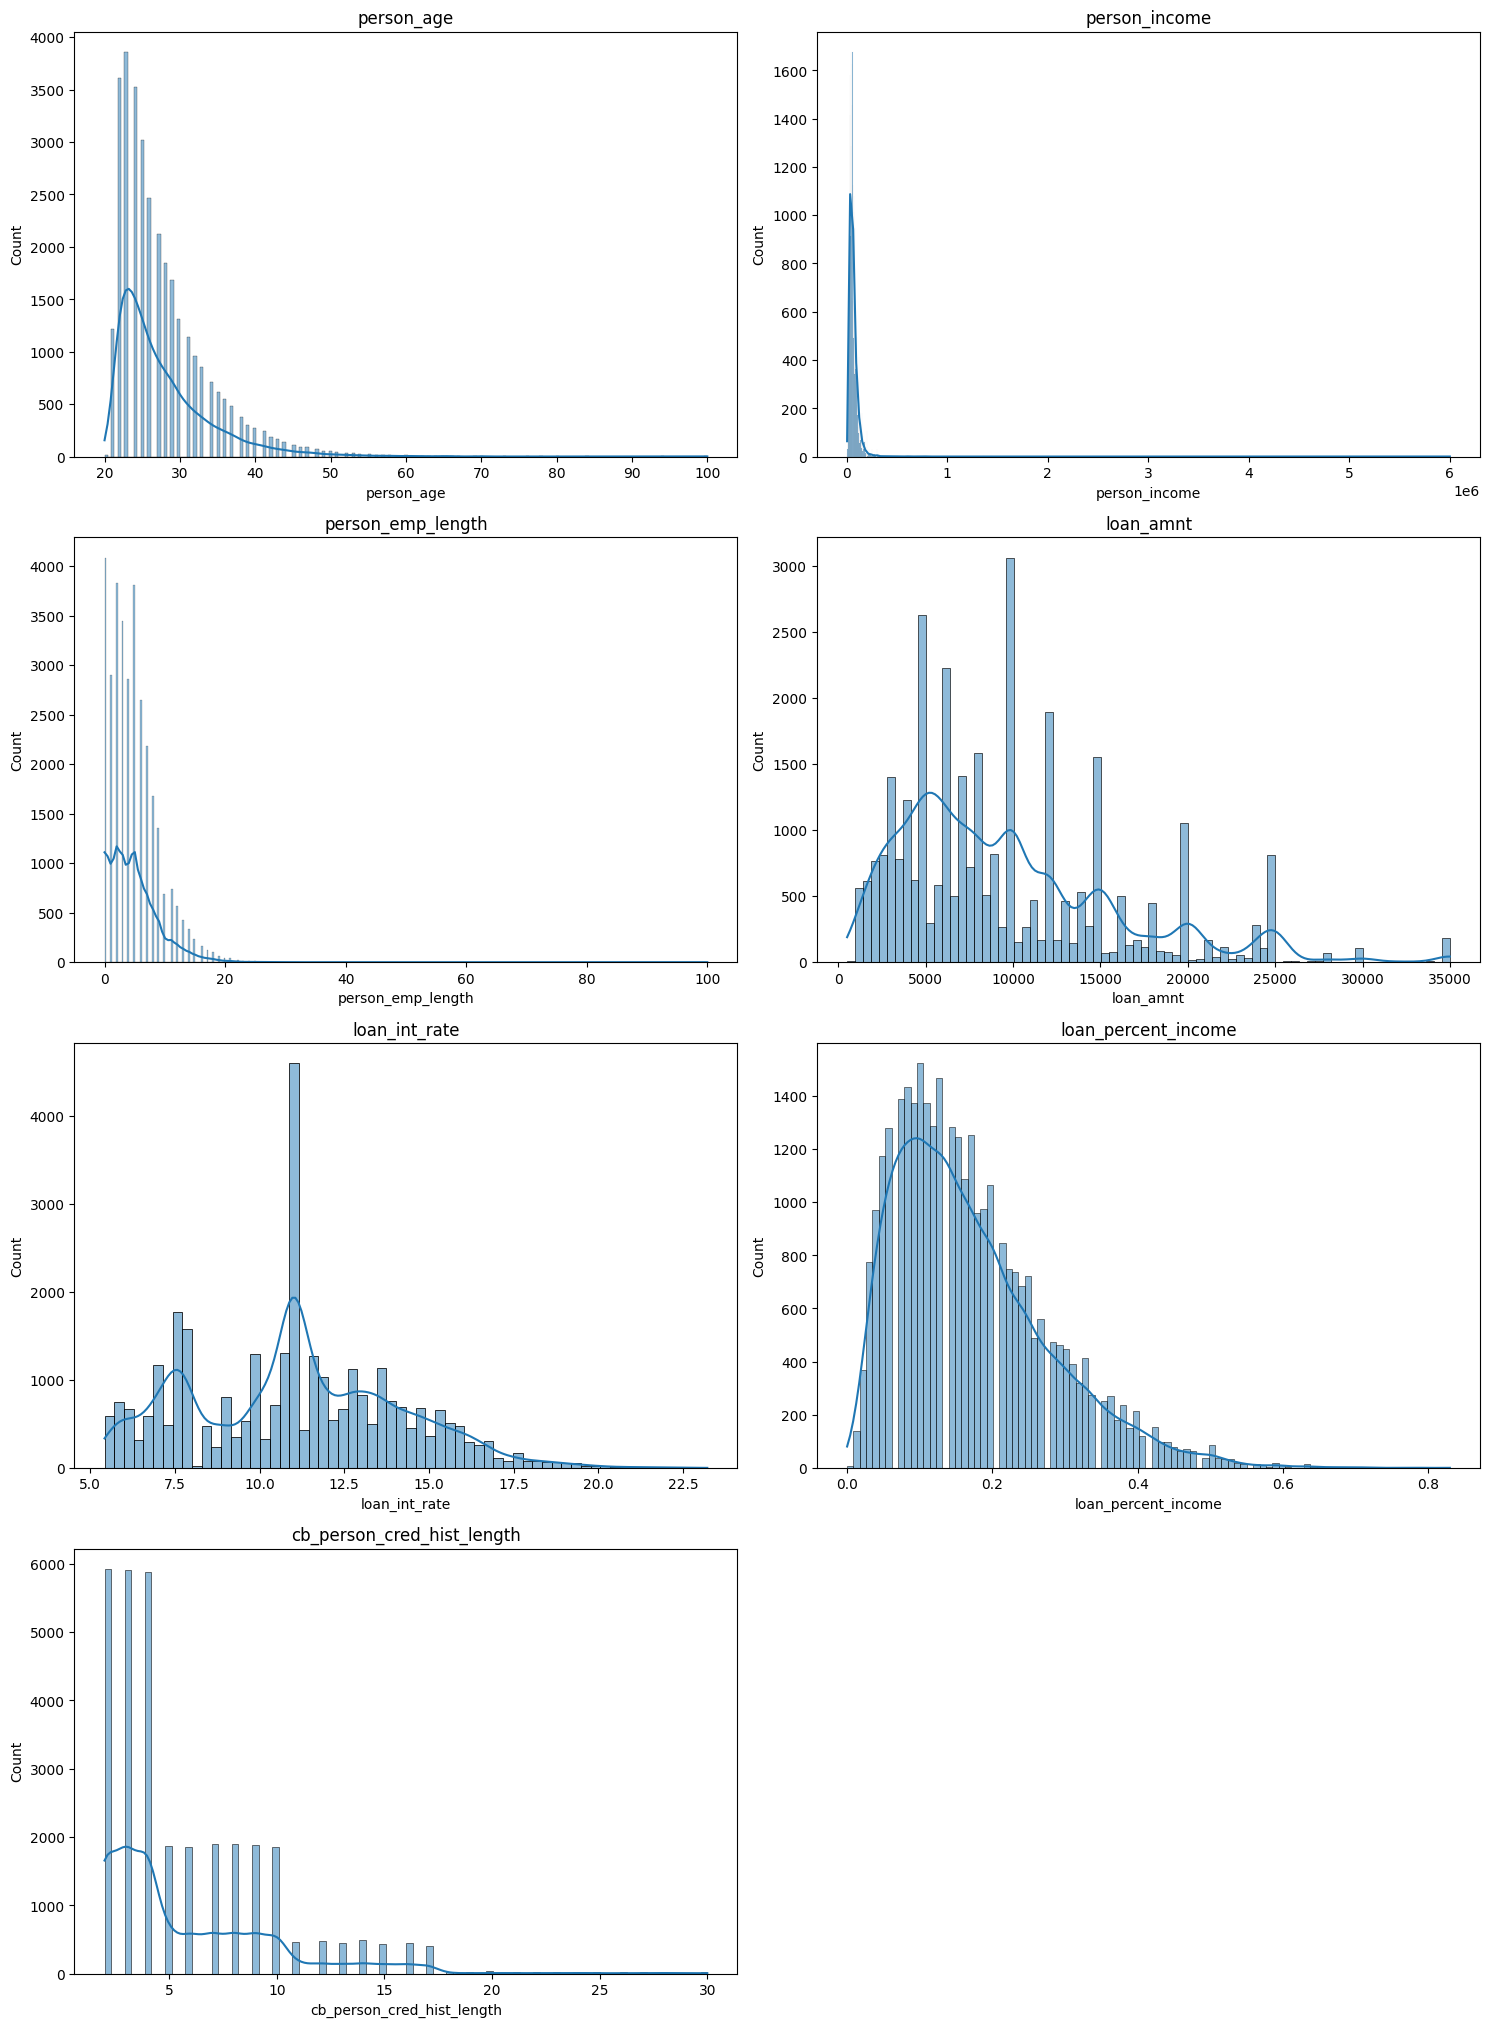

In [14]:
plt.figure(figsize=(15, 25))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(5, 2, i)
    sns.histplot(cred_risk_copy[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

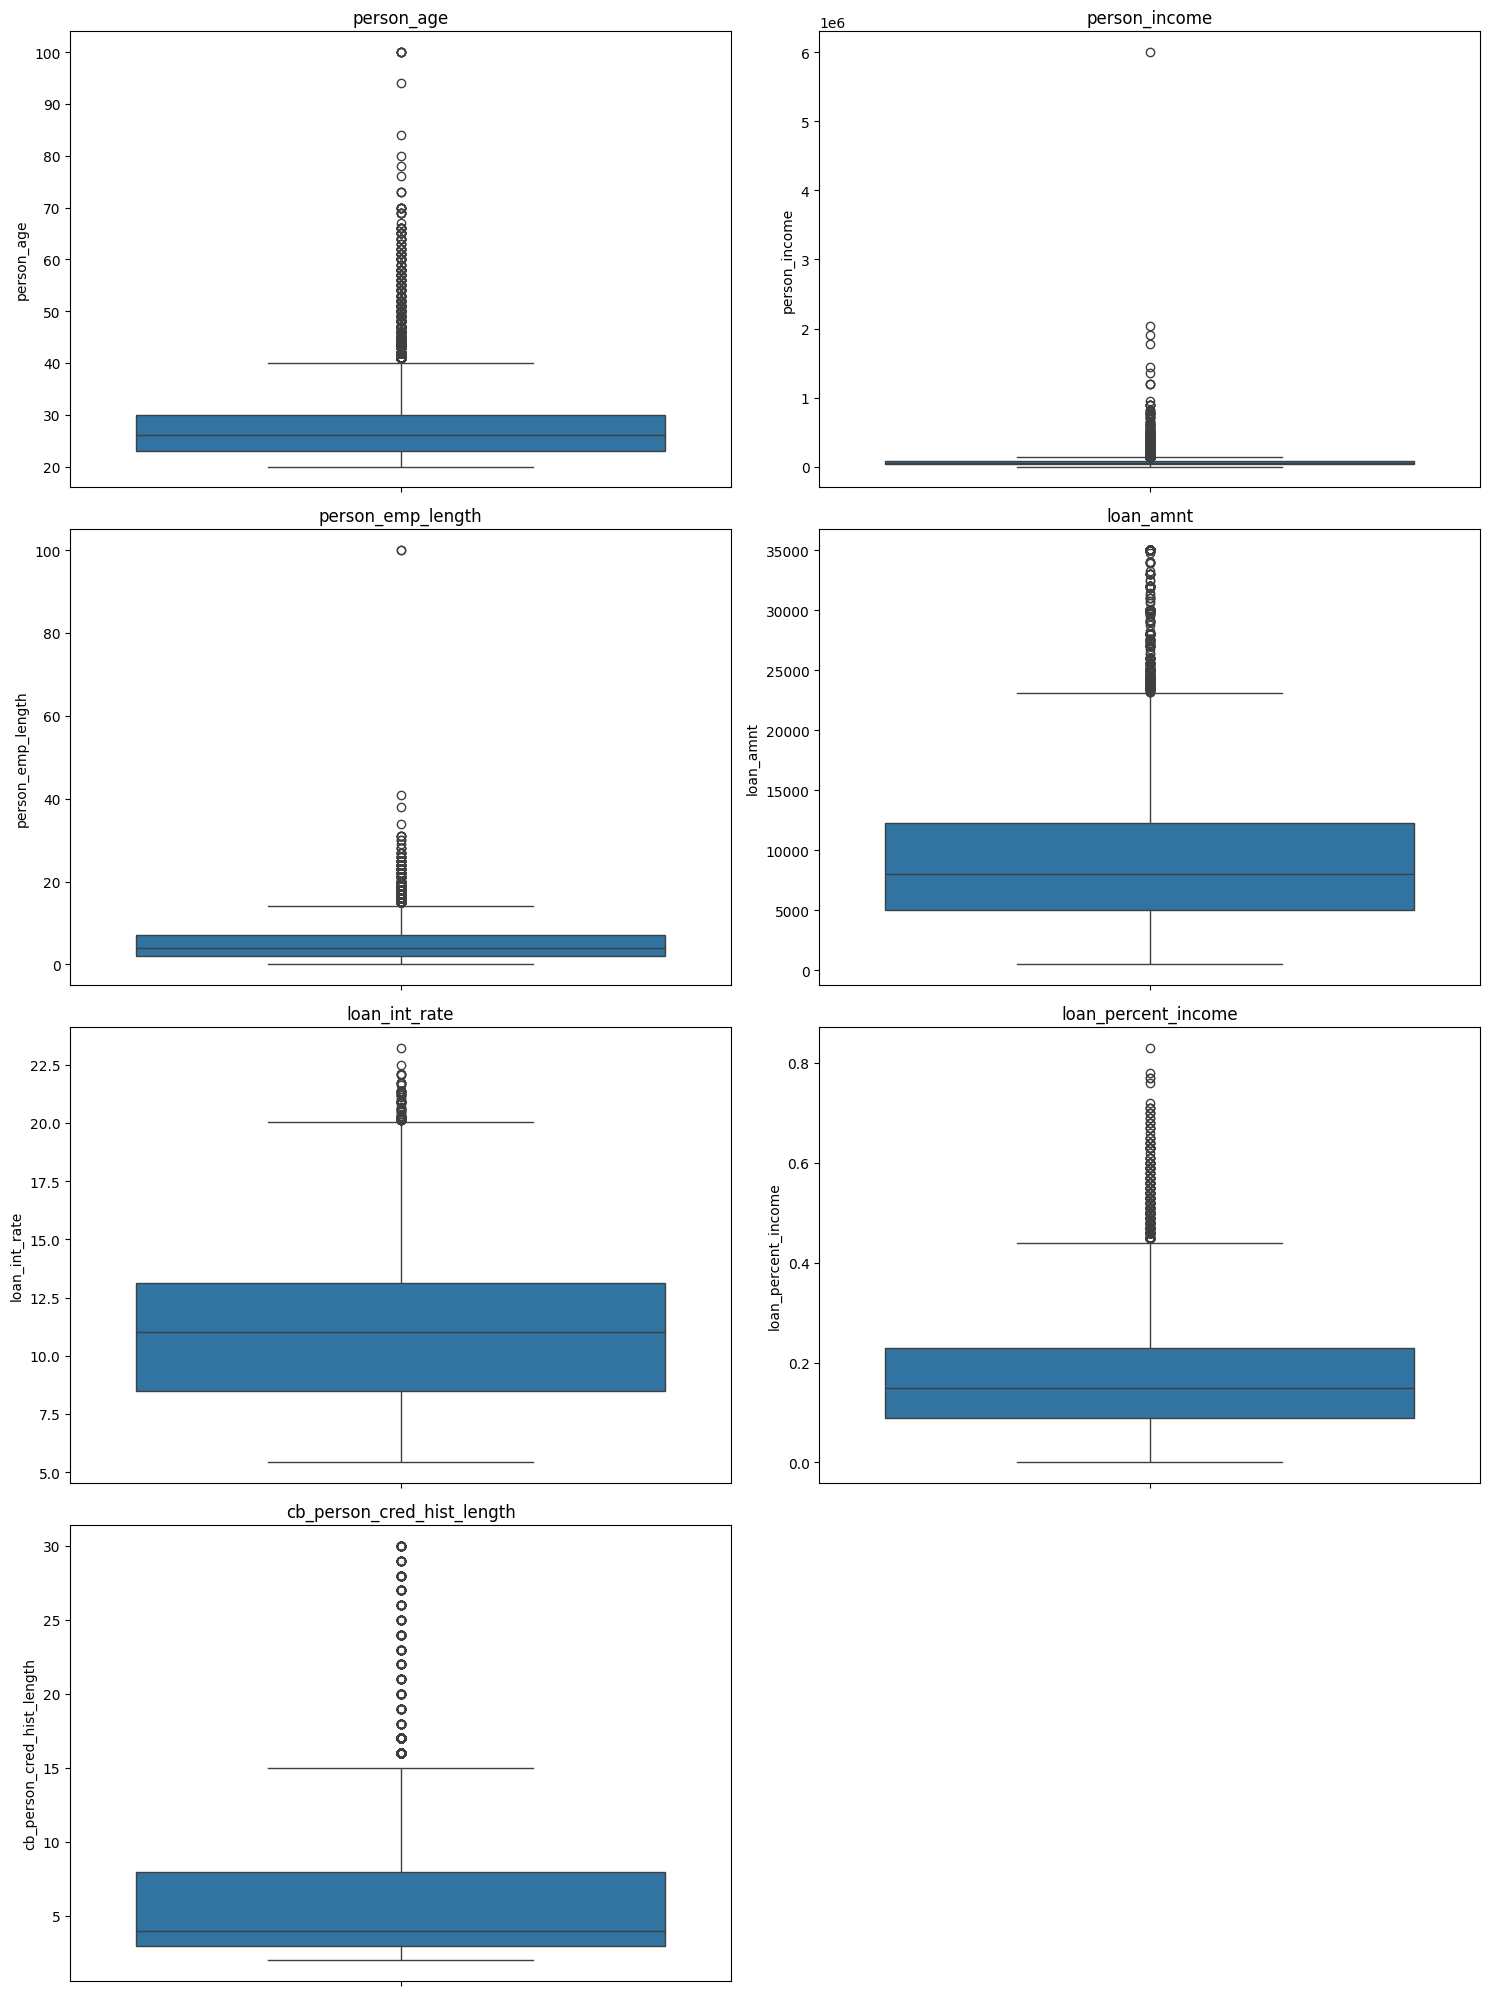

In [15]:
plt.figure(figsize=(15, 25))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(5, 2, i)
    sns.boxplot(cred_risk_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
cred_risk_copy[num_cols].skew()

,0
person_age,2.113581
person_income,32.958748
person_emp_length,1.999476
loan_amnt,1.191944
loan_int_rate,0.217652
loan_percent_income,1.063811
cb_person_cred_hist_length,1.659369


#### Conclusion
Can not remove outliers as that can be relevent data

## Data Preprocessing

In [17]:
cred_risk_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.741517,6.609164e+04,4.789051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.274489,6.201558e+04,4.051169,6322.730241,3.083040,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.017265,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,100.000000,6.000000e+06,100.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [18]:
# Separating dataset into X and y
X = cred_risk_copy.drop(columns=['loan_status'])  # example target
y = cred_risk_copy['loan_status']

In [19]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
X_train

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
7173,23,75800,RENT,0.000000,PERSONAL,A,7000,6.54,0.09,N,2
16396,25,61959,RENT,9.000000,EDUCATION,C,25000,12.73,0.40,Y,4
21744,31,53088,RENT,0.000000,PERSONAL,A,6000,6.54,0.11,N,9
27805,27,228000,MORTGAGE,12.000000,HOMEIMPROVEMENT,A,6000,7.14,0.03,N,6
24563,29,54000,RENT,0.000000,PERSONAL,D,10000,14.96,0.19,N,9
...,...,...,...,...,...,...,...,...,...,...,...
1233,23,25000,MORTGAGE,4.000000,MEDICAL,A,5000,9.32,0.20,N,2
741,22,21600,MORTGAGE,4.789051,EDUCATION,A,4025,5.42,0.19,N,4
21985,28,81000,RENT,13.000000,VENTURE,A,6225,7.90,0.08,N,7
26335,30,100000,MORTGAGE,13.000000,PERSONAL,A,10000,6.17,0.10,N,9


In [21]:
# Log transformation to reduce skewness
X_train[num_cols] = np.log1p(X_train[num_cols])
X_test[num_cols]  = np.log1p(X_test[num_cols])

In [22]:
X_train

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
7173,3.178054,11.235867,RENT,0.000000,PERSONAL,A,8.853808,2.020222,0.086178,N,1.098612
16396,3.258097,11.034244,RENT,2.302585,EDUCATION,C,10.126671,2.619583,0.336472,Y,1.609438
21744,3.465736,10.879725,RENT,0.000000,PERSONAL,A,8.699681,2.020222,0.104360,N,2.302585
27805,3.332205,12.337105,MORTGAGE,2.564949,HOMEIMPROVEMENT,A,8.699681,2.096790,0.029559,N,1.945910
24563,3.401197,10.896758,RENT,0.000000,PERSONAL,D,9.210440,2.770086,0.173953,N,2.302585
...,...,...,...,...,...,...,...,...,...,...,...
1233,3.178054,10.126671,MORTGAGE,1.609438,MEDICAL,A,8.517393,2.334084,0.182322,N,1.098612
741,3.135494,9.980495,MORTGAGE,1.755968,EDUCATION,A,8.300529,1.859418,0.173953,N,1.609438
21985,3.367296,11.302217,RENT,2.639057,VENTURE,A,8.736489,2.186051,0.076961,N,2.079442
26335,3.433987,11.512935,MORTGAGE,2.639057,PERSONAL,A,9.210440,1.969906,0.095310,N,2.302585


In [23]:
X_train[num_cols].skew()

,0
person_age,1.211134
person_income,0.158600
person_emp_length,-0.486493
loan_amnt,-0.453727
loan_int_rate,-0.325528
loan_percent_income,0.811001
cb_person_cred_hist_length,0.489015


In [24]:
# Scale data
scaler = RobustScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [25]:
cat_cols = cred_risk_copy.select_dtypes(include = ['object']).columns
cat_cols = cat_cols.drop('loan_grade')

In [26]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

# Concatenate with numerical columns
X_train_final = pd.concat([X_train[num_cols], X_train_cat], axis=1)
X_test_final  = pd.concat([X_test[num_cols], X_test_cat], axis=1)

In [27]:
ord_cols = ['loan_grade']  # ordered categories

# Specify order
grade_order = ['A','B','C','D','E','F','G']

encoder = OrdinalEncoder(categories=[grade_order])

# Fit and transform train set
X_train_final[ord_cols] = encoder.fit_transform(X_train[ord_cols])

# Transform test set
X_test_final[ord_cols] = encoder.transform(X_test[ord_cols])

## Model Training and Performance matrices

In [28]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_final, y_train)

y_pred = log_reg.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8596545342381247

Confusion Matrix:
 [[4816  250]
 [ 660  758]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      5066
           1       0.75      0.53      0.62      1418

    accuracy                           0.86      6484
   macro avg       0.82      0.74      0.77      6484
weighted avg       0.85      0.86      0.85      6484



In [29]:
scores = cross_val_score(
    log_reg,
    X_train_final,
    y_train,
    scoring='roc_auc',
    cv=5
)

print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.8712340361276084
